| | |
|---|---|
| **Project name** | Nationalistic Bias and Score Compression in Elite Diving Judging (2000–2025) |
| **Team name** | Team Jack |
| **Team member** | Jack Ryan — jryan303@stanford.edu |
| **Discussion section** | 5 |
| **Github Repo** | https://github.com/jackymike/omega-timing-diving-dataset |

**DATASCI 112 — Summer 2026**

## Setup


In [58]:
# Libraries we use in this notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import confusion_matrix, classification_report

# So train/test splits are the same each run
np.random.seed(42)

# Simple plot defaults
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Colors we reuse in figures (colorblind-friendly)
SAME_COLORS = {1: "#E69F00", 0: "#009E73"}  # same-country, other-country
YEAR_COLOR = "#0072B2"
FINAL_COLOR = "#D55E00"  # finals-only series on year plots
YEAR_PALETTE = ["#0072B2", "#E69F00", "#009E73"]  # selected-year overlays

pd.set_option("display.max_columns", 40)


In [90]:
from pathlib import Path

# Prefer the published dataset repo; if that fails, use the local CSVs
BASE = "https://raw.githubusercontent.com/jackymike/omega-timing-diving-dataset/main"
LOCAL_DIR = Path("../data/processed")

def load_csv(filename):
    url = BASE + "/" + filename
    local_path = LOCAL_DIR / filename
    try:
        df = pd.read_csv(url)
        print("Loaded", filename, "from URL", df.shape)
        return df
    except Exception as e:
        df = pd.read_csv(local_path)
        print("Loaded", filename, "locally", df.shape, "(" + type(e).__name__ + ")")
        return df

scores = load_csv("scores.csv")
judge_scores = load_csv("judge_scores.csv")
judges = load_csv("judges.csv")
diving2000 = load_csv("Diving2000.csv")


Loaded scores.csv from URL (69687, 21)
Loaded judge_scores.csv from URL (69687, 29)
Loaded judges.csv from URL (5460, 10)
Loaded Diving2000.csv from URL (10787, 10)


In [60]:
display(scores.head())
display(judge_scores.head())
display(judges.head())
display(diving2000.head())


,Meet,MeetId,Event,Round,EventDate,Diver,Country,OverallRank,DiveNo,DiveCode,Difficulty,JScore1,JScore2,JScore3,JScore4,JScore5,JScore6,JScore7,PenaltyFlag,DivePoints,TotalPoints
0,European Championships 2000 (Diving),helsinki_2000_euro,MEN 1m Springboard Preliminary,Preliminary,NaN,SIRANIDIS Nikolaos,GRE,1,1,405C,3.1,7.5,7.5,7.5,7.5,7.5,7.5,8.0,False,69.75,336.72
1,European Championships 2000 (Diving),helsinki_2000_euro,MEN 1m Springboard Preliminary,Preliminary,NaN,SIRANIDIS Nikolaos,GRE,1,2,107C,3.0,4.5,4.0,4.5,4.0,4.5,4.0,4.5,False,38.70,336.72
2,European Championships 2000 (Diving),helsinki_2000_euro,MEN 1m Springboard Preliminary,Preliminary,NaN,SIRANIDIS Nikolaos,GRE,1,3,205C,3.0,6.5,6.5,7.0,5.5,6.5,6.5,7.0,False,59.40,336.72
3,European Championships 2000 (Diving),helsinki_2000_euro,MEN 1m Springboard Preliminary,Preliminary,NaN,SIRANIDIS Nikolaos,GRE,1,4,305C,3.0,5.5,6.5,6.0,5.0,6.0,6.5,7.0,False,54.90,336.72
4,European Championships 2000 (Diving),helsinki_2000_euro,MEN 1m Springboard Preliminary,Preliminary,NaN,SIRANIDIS Nikolaos,GRE,1,5,5351C,3.1,6.5,7.0,6.5,6.0,6.5,6.0,6.0,False,58.59,336.72


,Meet,MeetId,Event,Round,EventDate,Diver,Country,OverallRank,DiveNo,DiveCode,Difficulty,JScore1,JScore2,JScore3,JScore4,JScore5,JScore6,JScore7,PenaltyFlag,DivePoints,TotalPoints,JudgeName1,JudgeName2,JudgeName3,JudgeName4,JudgeName5,JudgeName6,JudgeName7,Panel
0,European Championships 2000 (Diving),helsinki_2000_euro,MEN 1m Springboard Preliminary,Preliminary,NaN,SIRANIDIS Nikolaos,GRE,1.0,1.0,405C,3.1,7.5,7.5,7.5,7.5,7.5,7.5,8.0,False,69.75,336.72,BOOTHROYD Sydney GBR,ILIADIS Evangelos GRE,CASTIONI Enzo ITA,EVANGULOV Alexei RUS,LINDBERG Mathz SWE,KELEMEN Ildiko HUN,BARSUKOV Olexandr UKR,B
1,European Championships 2000 (Diving),helsinki_2000_euro,MEN 1m Springboard Preliminary,Preliminary,NaN,SIRANIDIS Nikolaos,GRE,1.0,2.0,107C,3.0,4.5,4.0,4.5,4.0,4.5,4.0,4.5,False,38.70,336.72,BOOTHROYD Sydney GBR,ILIADIS Evangelos GRE,CASTIONI Enzo ITA,EVANGULOV Alexei RUS,LINDBERG Mathz SWE,KELEMEN Ildiko HUN,BARSUKOV Olexandr UKR,B
2,European Championships 2000 (Diving),helsinki_2000_euro,MEN 1m Springboard Preliminary,Preliminary,NaN,SIRANIDIS Nikolaos,GRE,1.0,3.0,205C,3.0,6.5,6.5,7.0,5.5,6.5,6.5,7.0,False,59.40,336.72,BOOTHROYD Sydney GBR,ILIADIS Evangelos GRE,CASTIONI Enzo ITA,EVANGULOV Alexei RUS,LINDBERG Mathz SWE,KELEMEN Ildiko HUN,BARSUKOV Olexandr UKR,B
3,European Championships 2000 (Diving),helsinki_2000_euro,MEN 1m Springboard Preliminary,Preliminary,NaN,SIRANIDIS Nikolaos,GRE,1.0,4.0,305C,3.0,5.5,6.5,6.0,5.0,6.0,6.5,7.0,False,54.90,336.72,BOOTHROYD Sydney GBR,ILIADIS Evangelos GRE,CASTIONI Enzo ITA,EVANGULOV Alexei RUS,LINDBERG Mathz SWE,KELEMEN Ildiko HUN,BARSUKOV Olexandr UKR,B
4,European Championships 2000 (Diving),helsinki_2000_euro,MEN 1m Springboard Preliminary,Preliminary,NaN,SIRANIDIS Nikolaos,GRE,1.0,5.0,5351C,3.1,6.5,7.0,6.5,6.0,6.5,6.0,6.0,False,58.59,336.72,BOOTHROYD Sydney GBR,ILIADIS Evangelos GRE,CASTIONI Enzo ITA,EVANGULOV Alexei RUS,LINDBERG Mathz SWE,KELEMEN Ildiko HUN,BARSUKOV Olexandr UKR,B


,Meet,MeetId,Event,Round,EventDate,Panel,RoundsCovered,Function,JudgeNo,JudgeName
0,European Championships 2000 (Diving),helsinki_2000_euro,MEN 1m Springboard Preliminary,Preliminary,NaN,A,1-6,Judge 1,J1,HUBER Peter AUT
1,European Championships 2000 (Diving),helsinki_2000_euro,MEN 1m Springboard Preliminary,Preliminary,NaN,B,1-6,Judge 1,J1,BOOTHROYD Sydney GBR
2,European Championships 2000 (Diving),helsinki_2000_euro,MEN 1m Springboard Preliminary,Preliminary,NaN,A,1-6,Judge 2,J2,NARYCHKINE Vladimir BLR
3,European Championships 2000 (Diving),helsinki_2000_euro,MEN 1m Springboard Preliminary,Preliminary,NaN,B,1-6,Judge 2,J2,ILIADIS Evangelos GRE
4,European Championships 2000 (Diving),helsinki_2000_euro,MEN 1m Springboard Preliminary,Preliminary,NaN,A,1-6,Judge 3,J3,MATTURI-SLOTTE Marja FIN


,Event,Round,Diver,Country,Rank,DiveNo,Difficulty,JScore,Judge,JCountry
0,M3mSB,Final,XIONG Ni,CHN,1,1,3.1,8.0,RUIZ-PEDREGUERA Rolando,CUB
1,M3mSB,Final,XIONG Ni,CHN,1,1,3.1,9.0,GEAR Dennis,NZL
2,M3mSB,Final,XIONG Ni,CHN,1,1,3.1,8.5,BOYS Beverley,CAN
3,M3mSB,Final,XIONG Ni,CHN,1,1,3.1,8.5,JOHNSON Bente,NOR
4,M3mSB,Final,XIONG Ni,CHN,1,1,3.1,8.5,BOUSSARD Michel,FRA


In [97]:
jack = scores[scores["Diver"].str.contains(r"(?i)(?:\d*)RYAN\s+Jack\b", na=False)].copy()

results = (
    jack.sort_values("DiveNo")
    .groupby(["Meet", "Event", "Round"], as_index=False)
    .agg(
        Finish=("OverallRank", "last"),
        TotalPoints=("TotalPoints", "last"),
        n_dives=("DiveNo", "size"),
    )
)
display(results)

top_dives = (
    jack[
        [
            "Meet",
            "Event",
            "Round",
            "DiveNo",
            "DiveCode",
            "Difficulty",
            "JScore1",
            "JScore2",
            "JScore3",
            "JScore4",
            "JScore5",
            "JScore6",
            "JScore7",
            "DivePoints",
        ]
    ]
    .sort_values("DivePoints", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
display(top_dives)


,Meet,Event,Round,Finish,TotalPoints,n_dives
0,World Aquatics Championships 2023,1m Springboard Men Final,Final,9,376.35,6
1,World Aquatics Championships 2023,1m Springboard Men Preliminary,Preliminary,8,363.75,6
2,World Aquatics Championships 2024,Men's 1m Springboard Preliminary,Preliminary,27,270.10,6
3,World Aquatics Diving World Cup 2025 (Stop 2),Men's 3m Springboard Preliminary,Preliminary,14,368.90,6
4,World Aquatics Diving World Cup 2026 (Stop 1),Men's 3m Springboard Preliminary,Preliminary,5,443.45,6


,Meet,Event,Round,DiveNo,DiveCode,Difficulty,JScore1,JScore2,JScore3,JScore4,JScore5,JScore6,JScore7,DivePoints
0,World Aquatics Diving World Cup 2026 (Stop 1),Men's 3m Springboard Preliminary,Preliminary,5,5156B,3.9,7.0,7.0,7.0,7.0,7.0,6.5,6.5,81.90
1,World Aquatics Diving World Cup 2026 (Stop 1),Men's 3m Springboard Preliminary,Preliminary,6,109C,3.8,7.0,7.0,6.5,7.0,7.0,7.0,7.0,79.80
2,World Aquatics Diving World Cup 2026 (Stop 1),Men's 3m Springboard Preliminary,Preliminary,4,307C,3.5,8.0,7.5,7.0,7.5,7.5,7.5,7.0,78.75
3,World Aquatics Diving World Cup 2026 (Stop 1),Men's 3m Springboard Preliminary,Preliminary,1,5337D,3.5,7.5,7.5,7.0,7.5,7.5,7.0,7.0,77.00
4,World Aquatics Diving World Cup 2025 (Stop 2),Men's 3m Springboard Preliminary,Preliminary,6,5337D,3.5,7.0,7.0,7.0,7.0,6.5,7.0,7.0,73.50
5,World Aquatics Championships 2023,1m Springboard Men Final,Final,6,5335D,3.0,8.5,8.0,8.0,7.0,8.0,8.0,8.5,72.00
6,World Aquatics Championships 2023,1m Springboard Men Preliminary,Preliminary,6,5335D,3.0,8.0,8.0,8.0,8.5,8.0,8.5,7.5,72.00
7,World Aquatics Championships 2023,1m Springboard Men Final,Final,5,305C,3.0,8.0,8.5,8.0,7.5,7.5,8.0,7.5,70.50
8,World Aquatics Championships 2023,1m Springboard Men Final,Final,3,5152B,3.2,7.0,7.5,7.0,7.5,7.5,7.0,7.0,68.80
9,World Aquatics Diving World Cup 2025 (Stop 2),Men's 3m Springboard Preliminary,Preliminary,3,205B,3.0,7.5,7.5,7.5,7.5,7.0,7.5,8.0,67.50


In [61]:
# Columns that stay the same for every judge on a dive
id_cols = [
    "Meet", "MeetId", "Event", "Round", "EventDate",
    "Diver", "Country", "OverallRank", "DiveNo", "DiveCode",
    "Difficulty", "PenaltyFlag", "DivePoints", "TotalPoints", "Panel",
]

# Give every original dive row an id (used later for the panel comparison)
judge_scores = judge_scores.copy()
judge_scores["dive_id"] = range(len(judge_scores))
id_cols = ["dive_id"] + id_cols

# Stack the seven scores
score_long = judge_scores.melt(
    id_vars=id_cols,
    value_vars=["JScore1", "JScore2", "JScore3", "JScore4", "JScore5", "JScore6", "JScore7"],
    var_name="JudgeSeat",
    value_name="JScore",
)

# Stack the seven judge names the same way
name_long = judge_scores.melt(
    id_vars=id_cols,
    value_vars=[
        "JudgeName1", "JudgeName2", "JudgeName3", "JudgeName4",
        "JudgeName5", "JudgeName6", "JudgeName7",
    ],
    var_name="JudgeSeat",
    value_name="JudgeName",
)

# Judge number 1-7 from the column name (JScore3 -> 3, JudgeName3 -> 3)
score_long["JudgeNo"] = score_long["JudgeSeat"].str.replace("JScore", "").astype(int)
name_long["JudgeNo"] = name_long["JudgeSeat"].str.replace("JudgeName", "").astype(int)

# Put scores and names on the same rows
omega_long = score_long.merge(
    name_long[id_cols + ["JudgeNo", "JudgeName"]],
    on=id_cols + ["JudgeNo"],
    how="left",
)

# Year from MeetId, e.g. antalya_2025 -> 2025
omega_long["Year"] = omega_long["MeetId"].str.extract(r"(20\d{2})").astype(float)

print("omega_long shape:", omega_long.shape)
print("expected rows (dives x 7):", len(judge_scores) * 7)
print("years:", omega_long["Year"].min(), "to", omega_long["Year"].max())
omega_long[["MeetId", "Year", "Event", "Diver", "Country", "DiveNo", "JudgeNo", "JudgeName", "JScore"]].head(10)


omega_long shape: (487809, 21)
expected rows (dives x 7): 487809
years: 2000.0 to 2026.0


,MeetId,Year,Event,Diver,Country,DiveNo,JudgeNo,JudgeName,JScore
0,helsinki_2000_euro,2000.0,MEN 1m Springboard Preliminary,SIRANIDIS Nikolaos,GRE,1.0,1,BOOTHROYD Sydney GBR,7.5
1,helsinki_2000_euro,2000.0,MEN 1m Springboard Preliminary,SIRANIDIS Nikolaos,GRE,2.0,1,BOOTHROYD Sydney GBR,4.5
2,helsinki_2000_euro,2000.0,MEN 1m Springboard Preliminary,SIRANIDIS Nikolaos,GRE,3.0,1,BOOTHROYD Sydney GBR,6.5
3,helsinki_2000_euro,2000.0,MEN 1m Springboard Preliminary,SIRANIDIS Nikolaos,GRE,4.0,1,BOOTHROYD Sydney GBR,5.5
4,helsinki_2000_euro,2000.0,MEN 1m Springboard Preliminary,SIRANIDIS Nikolaos,GRE,5.0,1,BOOTHROYD Sydney GBR,6.5
5,helsinki_2000_euro,2000.0,MEN 1m Springboard Preliminary,SIRANIDIS Nikolaos,GRE,6.0,1,BOOTHROYD Sydney GBR,7.0
6,helsinki_2000_euro,2000.0,MEN 1m Springboard Preliminary,BAIBAKOV Dmitry,RUS,1.0,1,BOOTHROYD Sydney GBR,7.0
7,helsinki_2000_euro,2000.0,MEN 1m Springboard Preliminary,BAIBAKOV Dmitry,RUS,2.0,1,BOOTHROYD Sydney GBR,7.0
8,helsinki_2000_euro,2000.0,MEN 1m Springboard Preliminary,BAIBAKOV Dmitry,RUS,3.0,1,BOOTHROYD Sydney GBR,7.5
9,helsinki_2000_euro,2000.0,MEN 1m Springboard Preliminary,BAIBAKOV Dmitry,RUS,4.0,1,BOOTHROYD Sydney GBR,6.5


Judge country (`JCountry`)

In older meets, the judge name often ends with a country code (example: `BOOTHROYD Sydney GBR`). We pull off that last three-letter code when it is there. Newer meets usually do not print it, so those rows stay blank unless we have a lookup CSV.


In [62]:
# Try to read a trailing country code like "GBR" at the end of the name
omega_long["JCountry"] = omega_long["JudgeName"].str.extract(r"([A-Z]{3})$")

# Name without that code (for joining a lookup table)
omega_long["JudgeNameClean"] = omega_long["JudgeName"].str.replace(
    r"\s+[A-Z]{3}$", "", regex=True
)

# Fill in missing countries from the published judge-country lookup
lookup = load_csv("judge_country_lookup.csv")
omega_long = omega_long.merge(lookup, on="JudgeNameClean", how="left", suffixes=("", "_lookup"))
# use lookup country only where we did not already get one from the name
missing = omega_long["JCountry"].isna()
omega_long.loc[missing, "JCountry"] = omega_long.loc[missing, "JCountry_lookup"]
omega_long = omega_long.drop(columns=["JCountry_lookup"])
print("Filled missing countries from judge_country_lookup.csv")

print("Fraction with JCountry by year:")
print(omega_long.groupby("Year")["JCountry"].apply(lambda s: s.notna().mean()).round(2))


Filled missing countries from ../data/processed/judge_country_lookup.csv
Fraction with JCountry by year:
Year
2000.0    0.95
2001.0    0.56
2002.0    1.00
2003.0    0.83
2004.0    0.95
2005.0    0.96
2006.0    0.95
2007.0    0.92
2008.0    0.92
2009.0    0.92
2010.0    0.91
2011.0    0.90
2012.0    0.91
2013.0    0.20
2014.0    0.48
2015.0    0.33
2016.0    0.52
2017.0    0.25
2018.0    0.15
2019.0    0.82
2020.0    1.00
2021.0    0.06
2022.0    0.07
2023.0    0.11
2024.0    0.10
2025.0    0.34
2026.0    0.03
Name: JCountry, dtype: float64


Same-country flag

Mark rows where the judge and diver are from the same country. For Omega, if we do not know the judge’s country yet, we leave `SameCountry` as missing.


In [63]:
# Diving2000
diving2000 = diving2000.copy()
diving2000["SameCountry"] = (diving2000["JCountry"] == diving2000["Country"]).astype(int)
diving2000["Year"] = 2000
diving2000["Source"] = "Diving2000"

# Omega 
# True/False if country known, NaN otherwise
omega_long["SameCountry"] = np.where(
    omega_long["JCountry"].isna(),
    np.nan,
    (omega_long["JCountry"] == omega_long["Country"]).astype(float),
)
omega_long["Source"] = "Omega"

print("Diving2000 SameCountry counts:")
print(diving2000["SameCountry"].value_counts())
print()
print("Omega SameCountry counts (NaN means judge country unknown):")
print(omega_long["SameCountry"].value_counts(dropna=False))


Diving2000 SameCountry counts:
SameCountry
0    10473
1      314
Name: count, dtype: int64

Omega SameCountry counts (NaN means judge country unknown):
SameCountry
NaN    239603
0.0    239455
1.0      8751
Name: count, dtype: int64


Within-dive discrepancy

For each score, we compare it to the average of the **other** judges on the same dive:

`Discrepancy = JScore - (panel sum - my score) / 6`

A positive discrepancy means this judge scored higher than the rest of the panel.


In [64]:
# use dive_id for OMEGA
dive_stats = omega_long.groupby("dive_id")["JScore"].agg(["sum", "count"])
dive_stats = dive_stats.rename(columns={"sum": "panel_sum", "count": "panel_n"})
dive_stats = dive_stats.reset_index()

omega_long = omega_long.merge(dive_stats, on="dive_id", how="left")
omega_long["loo_mean"] = (omega_long["panel_sum"] - omega_long["JScore"]) / (omega_long["panel_n"] - 1)
omega_long["Discrepancy"] = omega_long["JScore"] - omega_long["loo_mean"]

# group by event, round, diver, dive number for Diving2000
d2000_stats = diving2000.groupby(["Event", "Round", "Diver", "DiveNo"])["JScore"].agg(["sum", "count"])
d2000_stats = d2000_stats.rename(columns={"sum": "panel_sum", "count": "panel_n"})
d2000_stats = d2000_stats.reset_index()

diving2000 = diving2000.merge(d2000_stats, on=["Event", "Round", "Diver", "DiveNo"], how="left")
diving2000["loo_mean"] = (diving2000["panel_sum"] - diving2000["JScore"]) / (diving2000["panel_n"] - 1)
diving2000["Discrepancy"] = diving2000["JScore"] - diving2000["loo_mean"]

print("Omega Discrepancy summary:")
print(omega_long["Discrepancy"].describe())
print()
print("Diving2000 Discrepancy summary:")
print(diving2000["Discrepancy"].describe())
print()
print("Omega panel sizes (should be 7):")
print(omega_long.groupby("dive_id").size().value_counts())


Omega Discrepancy summary:
count    4.878090e+05
mean    -5.010705e-18
std      4.309530e-01
min     -4.666667e+00
25%     -2.500000e-01
50%      0.000000e+00
75%      2.500000e-01
max      3.833333e+00
Name: Discrepancy, dtype: float64

Diving2000 Discrepancy summary:
count    1.078700e+04
mean    -9.077748e-18
std      4.777227e-01
min     -3.000000e+00
25%     -2.500000e-01
50%      0.000000e+00
75%      3.333333e-01
max      2.250000e+00
Name: Discrepancy, dtype: float64

Omega panel sizes (should be 7):
7    69687
Name: count, dtype: int64


Difficulty bands and event labels

We bin degree of difficulty so we can compare score distributions within similar dive difficulty. We also make a short event label (like `M3mSB`) from the long Omega event titles.


In [65]:
# Difficulty bins (same for both datasets)
# DD under 1.0 or higher than 5.0 is not possible.
# currently the highest dd dive done in competition is 109b on 3m (DD 4.2) 
dd_bins = [1.0, 2.5, 3.0, 3.5, 4.0, 4.5]
dd_labels = ["<=2.5", "2.5-3.0", "3.0-3.5", "3.5-4.0", ">4.0"]

omega_long["DD_band"] = pd.cut(
    omega_long["Difficulty"], bins=dd_bins, labels=dd_labels, include_lowest=True
)
diving2000["DD_band"] = pd.cut(
    diving2000["Difficulty"], bins=dd_bins, labels=dd_labels, include_lowest=True
)

# Turn long event titles into short codes like M3mSB / W10mPF
def event_family(event):
    e = str(event).lower()

    if "women" in e or e.startswith("w"):
        sex = "W"
    elif "men" in e or e.startswith("m"):
        sex = "M"
    else:
        sex = "?"

    e_nospace = e.replace(" ", "")
    if "1m" in e_nospace:
        board = "1m"
    elif "3m" in e_nospace:
        board = "3m"
    elif "10m" in e_nospace or "platform" in e:
        board = "10m"
    else:
        board = "?"

    return sex + board

omega_long["EventFamily"] = omega_long["Event"].apply(event_family)
diving2000["EventFamily"] = diving2000["Event"]  # already short codes

# Helpful flags for Question 3
omega_long["Is10"] = (omega_long["JScore"] == 10).astype(int)
omega_long["IsHigh"] = (omega_long["JScore"] >= 9).astype(int)
diving2000["Is10"] = (diving2000["JScore"] == 10).astype(int)
diving2000["IsHigh"] = (diving2000["JScore"] >= 9).astype(int)

print("Omega EventFamily counts:")
print(omega_long["EventFamily"].value_counts())
print()
print("Omega DD_band counts:")
print(omega_long["DD_band"].value_counts().sort_index())


Omega EventFamily counts:
EventFamily
M3m     120596
M10m     99463
W3m      88907
W10m     83846
M1m      49077
W1m      37408
??        8512
Name: count, dtype: int64

Omega DD_band counts:
DD_band
<=2.5       42224
2.5-3.0    200767
3.0-3.5    199647
3.5-4.0     44079
>4.0         1092
Name: count, dtype: int64


## Nationalistic judging bias

Do judges award higher scores to divers from their own country than the rest of the panel would predict? Has that same-country premium changed across years from 2000 to today?

### Replicate on Diving2000

Positive discrepancy means a judge scored a dive higher than the other six on that panel.


Diving2000 discrepancy by SameCountry:
               count   mean  median
Other country  10473 -0.008    0.00
Same country     314  0.282    0.25

premium (same - other): 0.291 points


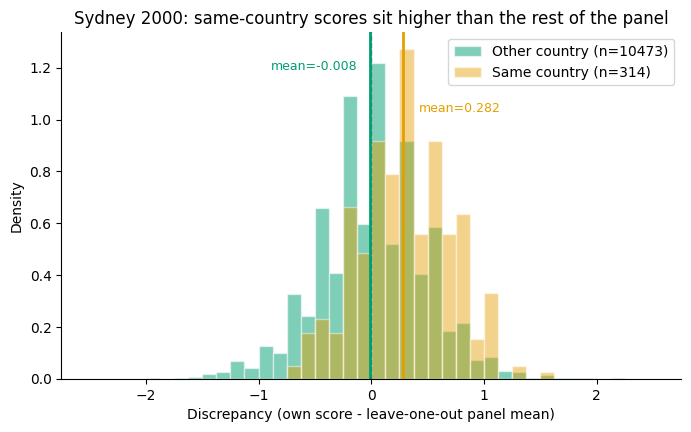

In [66]:
# how does discrepancy look for same-country vs mismatch
# group by SameCountry and then count / mean / median of Discrepancy
d2000_summary = diving2000.groupby("SameCountry")["Discrepancy"].agg(["count", "mean", "median"])
d2000_summary.index = ["Other country", "Same country"]
print("Diving2000 discrepancy by SameCountry:")
print(d2000_summary.round(3))

# premium = avg(same country discrepancy) - avg(other-country discrepancy)
# Positive value -> same country judges score higher than the rest of the panel
d2000_premium = (
    diving2000.loc[diving2000["SameCountry"] == 1, "Discrepancy"].mean()
    - diving2000.loc[diving2000["SameCountry"] == 0, "Discrepancy"].mean()
)
print()
print("premium (same - other):", round(d2000_premium, 3), "points")

# split groups
same_disc = diving2000.loc[diving2000["SameCountry"] == 1, "Discrepancy"]
other_disc = diving2000.loc[diving2000["SameCountry"] == 0, "Discrepancy"]

same_mean = same_disc.mean()
other_mean = other_disc.mean()

# same bin edges for both histograms so shapes are comparable
disc_bins = np.linspace(-2.5, 2.5, 41)

# full histogram (not just the mean)
fig, ax = plt.subplots()
ax.hist(
    other_disc,
    bins=disc_bins,
    density=True,            # puts both groups on the same vertical scale
    alpha=0.5,              
    color=SAME_COLORS[0],
    edgecolor="white",
    label="Other country (n=" + str(len(other_disc)) + ")",
)
ax.hist(
    same_disc,
    bins=disc_bins,
    density=True,
    alpha=0.45,
    color=SAME_COLORS[1],
    edgecolor="white",
    label="Same country (n=" + str(len(same_disc)) + ")",
)

# mark zero (matches the panel) and each group's mean
ax.axvline(0, color="0.4", linestyle="--", linewidth=1)
ax.axvline(other_mean, color=SAME_COLORS[0], linestyle="-", linewidth=2)
ax.axvline(same_mean, color=SAME_COLORS[1], linestyle="-", linewidth=2)

# label the two means
y_top = ax.get_ylim()[1]
ax.text(other_mean - 0.5, y_top * 0.92, "mean=" + f"{other_mean:.3f}", color=SAME_COLORS[0],
        ha="center", va="top", fontsize=9)
ax.text(same_mean + 0.5, y_top * 0.80, "mean=" + f"{same_mean:.3f}", color=SAME_COLORS[1],
        ha="center", va="top", fontsize=9)

ax.set_xlabel("Discrepancy (own score - leave-one-out panel mean)")
ax.set_ylabel("Density")
ax.set_title("Sydney 2000: discrepancy by same-country vs other-country")
ax.legend()
plt.show()


## Regression check

We regress discrepancy on `SameCountry` and `Difficulty`. The `SameCountry` coefficient is another estimate of the premium, holding difficulty fixed. We use a train/test split and report RMSE the way we did in class.


In [67]:
# Features and target
X = diving2000[["SameCountry", "Difficulty"]]
y = diving2000["Discrepancy"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficients:")
print("  SameCountry:", round(model.coef_[0], 4))
print("  Difficulty: ", round(model.coef_[1], 4))
print("Intercept:", round(model.intercept_, 4))

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print("Test RMSE:", round(rmse, 4))
print("Test MAE: ", round(mae, 4))


Coefficients:
  SameCountry: 0.2773
  Difficulty:  0.0036
Intercept: -0.0189
Test RMSE: 0.4697
Test MAE:  0.3638


The regression agrees with the simple mean difference, and with Emerson et al. Holding difficulty fixed, the `SameCountry` coefficient is still about 0.28 points. Difficulty itself doesn't seem to matter (coefficient ≈ 0) which is what we should expect. The discrepancy already compares judges on the same dive.

The scoring bump is still in the same range Emerson reported: roughly a half-point bump, relative to the rest of the panel, on about half of same-country dives, regardless of difficulty.

I am guessing that the test RMSE (≈0.47) is larger than the premium because individual judges often disagree by half a point to a point anyway. 

### Apply to Omega scores (with known judge country)

We keep only Omega rows where `SameCountry` is not missing. 

Coverage is uneven by year (more matches in data before 2013 and where the lookup filled gaps).


Omega rows with known JCountry: 248206
SameCountry
0.0    239455
1.0      8751
Name: count, dtype: int64

Omega discrepancy by SameCountry:
                count   mean  median
Other country  239455 -0.003   0.000
Same country     8751  0.123   0.083

Omega pooled premium (same - other): 0.126 points


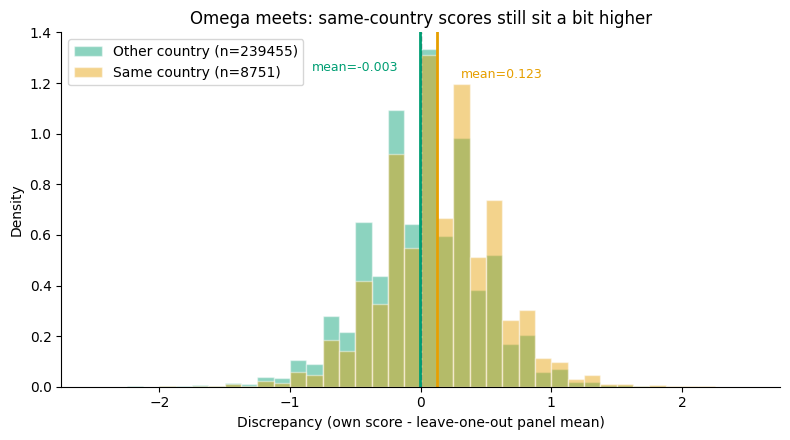


Omega regression SameCountry coef: 0.1218
Omega test RMSE: 0.4402


In [68]:
# rows where we know judge country
omega_known = omega_long[omega_long["SameCountry"].notna()].copy()
print("Omega rows with known JCountry:", len(omega_known))
print(omega_known["SameCountry"].value_counts())

omega_summary = omega_known.groupby("SameCountry")["Discrepancy"].agg(["count", "mean", "median"])
omega_summary.index = ["Other country", "Same country"]
print()
print("Omega discrepancy by SameCountry:")
print(omega_summary.round(3))

omega_premium = (
    omega_known.loc[omega_known["SameCountry"] == 1, "Discrepancy"].mean()
    - omega_known.loc[omega_known["SameCountry"] == 0, "Discrepancy"].mean()
)
print()
print("Omega pooled premium (same - other):", round(omega_premium, 3), "points")

same_o = omega_known.loc[omega_known["SameCountry"] == 1, "Discrepancy"]
other_o = omega_known.loc[omega_known["SameCountry"] == 0, "Discrepancy"]
same_o_mean = same_o.mean()
other_o_mean = other_o.mean()

# same bins as Diving2000
fig, ax = plt.subplots()
ax.hist(
    other_o,
    bins=disc_bins,
    density=True,
    alpha=0.45,
    color=SAME_COLORS[0],
    edgecolor="white",
    label="Other country (n=" + str(len(other_o)) + ")",
)
ax.hist(
    same_o,
    bins=disc_bins,
    density=True,
    alpha=0.45,
    color=SAME_COLORS[1],
    edgecolor="white",
    label="Same country (n=" + str(len(same_o)) + ")",
)

ax.axvline(0, color="0.4", linestyle="--", linewidth=1)
ax.axvline(other_o_mean, color=SAME_COLORS[0], linestyle="-", linewidth=2)
ax.axvline(same_o_mean, color=SAME_COLORS[1], linestyle="-", linewidth=2)

y_top = ax.get_ylim()[1]
ax.text(other_o_mean - 0.5, y_top * 0.92, "mean=" + f"{other_o_mean:.3f}", color=SAME_COLORS[0],
        ha="center", va="top", fontsize=9)
ax.text(same_o_mean + 0.5, y_top * 0.90, "mean=" + f"{same_o_mean:.3f}", color=SAME_COLORS[1],
        ha="center", va="top", fontsize=9)

ax.set_xlabel("Discrepancy (own score - leave-one-out panel mean)")
ax.set_ylabel("Density")
ax.set_title("Omega: discrepancy by same-country vs other-country")
ax.legend()
plt.tight_layout()
plt.show()

# same simple regression on Omega
X_o = omega_known[["SameCountry", "Difficulty"]]
y_o = omega_known["Discrepancy"]
X_tr, X_te, y_tr, y_te = train_test_split(X_o, y_o, test_size=0.3, random_state=42)
model_o = LinearRegression()
model_o.fit(X_tr, y_tr)
print()
print("Omega regression SameCountry coef:", round(model_o.coef_[0], 4))
print("Omega test RMSE:", round(np.sqrt(mean_squared_error(y_te, model_o.predict(X_te))), 4))


Omega results still agree with Emerson that there is a bias, but the bump is smaller than in Sydney 2000.

Same country scores sit about 0.13 points above the rest of the panel. The regression coefficient is almost the same (0.12), so difficulty again seems to have no effect. 

That is roughly half of the 0.29 point difference in Sydney. 0.13 points is comparable to a half point bump on about a quarter of same country dives, which does not feel that impactful overall. 

Slight disclaimer: Omega PDFs do not print judge nationality, so this is only the subset where I could attach a country to a known judge name. This was far more successful in meets in 2013 and earlier. 

### Premium over time (by year)


Years used (n_same >= 100):
  Year  n_same  n_other  premium
2000.0     279     8422    0.107
2002.0     453    12126    0.139
2003.0     290    12583    0.152
2004.0     431    10650    0.116
2005.0     623    16660    0.213
2006.0     878    13234    0.101
2007.0     381    16160    0.103
2008.0     438    10139    0.084
2009.0     377    14407    0.149
2010.0     240     7502    0.211
2011.0     528    20052    0.092
2012.0     296     6802    0.125
2013.0     112     4775    0.095
2014.0     168     7359    0.172
2015.0     625     9869    0.084
2016.0     420    11165    0.135
2017.0     291     6385    0.185
2018.0     103     2671    0.183
2019.0     819    23663    0.110
2020.0     166     2452    0.106
2023.0     144     2978    0.079
2024.0     168     3689    0.155
2025.0     405    11280    0.085


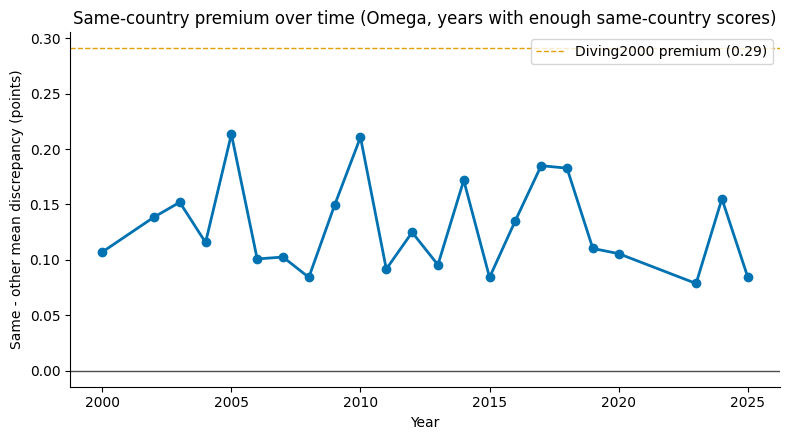

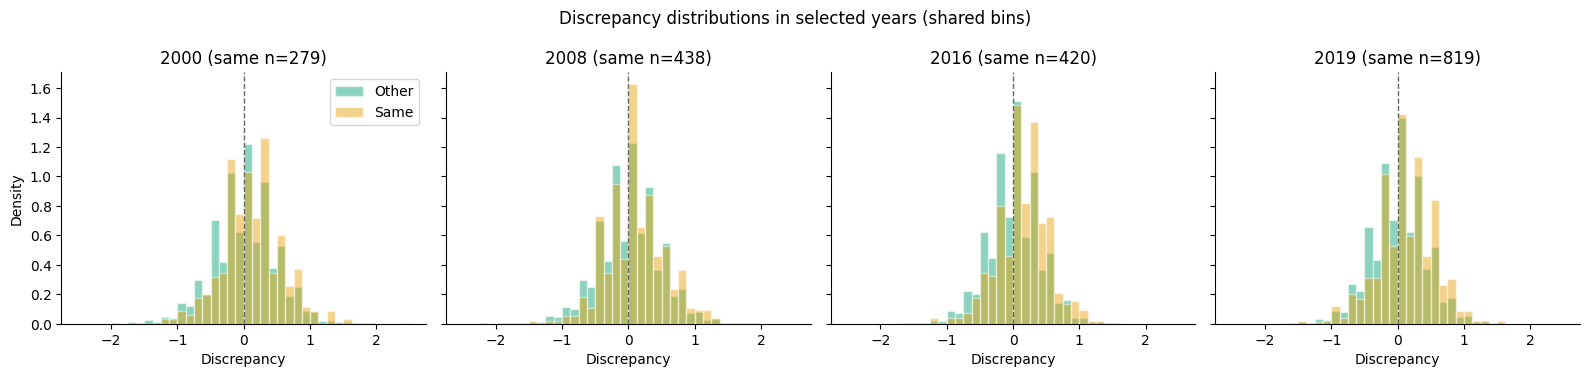

In [69]:
# mean discrepancy - by year and SameCountry
by_year = (
    omega_known.groupby(["Year", "SameCountry"])["Discrepancy"]
    .agg(["mean", "count"])
    .reset_index()
)

same_by_year = by_year[by_year["SameCountry"] == 1][["Year", "mean", "count"]]
same_by_year = same_by_year.rename(columns={"mean": "mean_same", "count": "n_same"})
other_by_year = by_year[by_year["SameCountry"] == 0][["Year", "mean", "count"]]
other_by_year = other_by_year.rename(columns={"mean": "mean_other", "count": "n_other"})

year_premium = same_by_year.merge(other_by_year, on="Year", how="inner")
year_premium["premium"] = year_premium["mean_same"] - year_premium["mean_other"]

# keep years with enough same-country scores
MIN_SAME = 100
year_premium_plot = year_premium[year_premium["n_same"] >= MIN_SAME].copy()
year_premium_plot = year_premium_plot.sort_values("Year")

print("Years used (n_same >= " + str(MIN_SAME) + "):")
print(year_premium_plot[["Year", "n_same", "n_other", "premium"]].round(3).to_string(index=False))

# premium vs year
fig, ax = plt.subplots()
ax.plot(
    year_premium_plot["Year"],
    year_premium_plot["premium"],
    color=YEAR_COLOR,
    marker="o",
    linewidth=2,
)
ax.axhline(0, color="0.3", linewidth=1)
# Diving2000 as reference line
ax.axhline(
    d2000_premium,
    color=SAME_COLORS[1],
    linestyle="--",
    linewidth=1,
    label="Diving2000 premium (" + str(round(d2000_premium, 2)) + ")",
)
ax.set_xlabel("Year")
ax.set_ylabel("Same - other mean discrepancy (points)")
ax.set_title("Same-country premium over time (Omega, years with enough same-country scores)")
ax.legend()
plt.tight_layout()
plt.show()

# small-multiple histograms for a few years with enough data
focus_years = []
for y in [2000, 2008, 2016, 2019]:
    n_same_y = ((omega_known["Year"] == y) & (omega_known["SameCountry"] == 1)).sum()
    if n_same_y >= MIN_SAME:
        focus_years.append(y)

if len(focus_years) == 0:
    # fall back to the years with the most same-country scores
    focus_years = list(
        year_premium_plot.sort_values("n_same", ascending=False)["Year"].head(3).astype(int)
    )

fig, axes = plt.subplots(1, len(focus_years), figsize=(4 * len(focus_years), 3.8), sharey=True)
if len(focus_years) == 1:
    axes = [axes]

for ax, year in zip(axes, focus_years):
    sub = omega_known[omega_known["Year"] == year]
    other_y = sub.loc[sub["SameCountry"] == 0, "Discrepancy"]
    same_y = sub.loc[sub["SameCountry"] == 1, "Discrepancy"]
    ax.hist(
        other_y,
        bins=disc_bins,
        density=True,
        alpha=0.45,
        color=SAME_COLORS[0],
        edgecolor="white",
        label="Other",
    )
    ax.hist(
        same_y,
        bins=disc_bins,
        density=True,
        alpha=0.45,
        color=SAME_COLORS[1],
        edgecolor="white",
        label="Same",
    )
    ax.axvline(0, color="0.4", linestyle="--", linewidth=1)
    ax.set_title(str(int(year)) + " (same n=" + str(len(same_y)) + ")")
    ax.set_xlabel("Discrepancy")

axes[0].set_ylabel("Density")
axes[0].legend()
fig.suptitle("Discrepancy distributions in selected years (shared bins)")
plt.tight_layout()
plt.show()


In the Sydney Olympics, judges from the same country as the athlete scored around 0.29 points higher than the other judges (on a 0–10 scale). The histogram is shifted right for these same country assignments, and the linear regression of discrepancy on SameCountry and Difficulty gives a positive SameCountry coefficient in the same direction.

On the other competitions (Omega) where judge country is known, there is still an increase in score but it is roughly half that of the Sydney 2000 Olympic file. Restricting to years with at least 100 same-country scores, the jump is positive in every year on the plot (≈ 0.08 to 0.21 points). It does not appear to be trending toward zero but it does not seem to trend upwardly either. 

2021 and 2022 do not meet the cutoff of 100 scores, and 2023 and 2024 still have thinner coverage than a typical year so those two points are less precise.

In [70]:
# summary
q1_summary = pd.DataFrame({
    "dataset": ["Diving2000", "Omega (known JCountry)"],
    "n_same": [
        int((diving2000["SameCountry"] == 1).sum()),
        int((omega_known["SameCountry"] == 1).sum()),
    ],
    "n_other": [
        int((diving2000["SameCountry"] == 0).sum()),
        int((omega_known["SameCountry"] == 0).sum()),
    ],
    "premium_mean_diff": [round(d2000_premium, 3), round(omega_premium, 3)],
    "regression_SameCountry_coef": [
        round(model.coef_[0], 3),
        round(model_o.coef_[0], 3),
    ],
})
q1_summary


,dataset,n_same,n_other,premium_mean_diff,regression_SameCountry_coef
0,Diving2000,314,10473,0.291,0.277
1,Omega (known JCountry),8751,239455,0.126,0.122


## Question 3 — The disappearing 10

Do judges award top scores (especially 10s) less often in recent years than in the early 2000s, even after accounting for harder dive lists?

Working hypothesis: the “10” has become rarer. Early checks on recent meets show far fewer perfect 10s than in Diving2000 / early Omega years.



## Top-score rates by year


Omega top-score rates by year (failed dives dropped):
  Year     n  tens_per_1000  high_per_1000  mean_score  mean_dd
2000.0  9198           2.50          27.61        6.46     2.79
2001.0  3835           0.26          17.47        6.42     2.97
2002.0 12591           0.95          15.01        6.41     2.92
2003.0 15411           3.18          36.60        6.56     2.86
2004.0 11648           0.94          20.35        6.64     2.73
2005.0 17988           2.56          59.93        6.84     2.81
2006.0 14858           2.49          34.59        6.69     2.93
2007.0 17946           5.74          56.39        6.64     3.02
2008.0 11517           1.39          22.75        6.46     2.95
2009.0 15931           2.45          65.28        6.95     3.07
2010.0  8491           1.88          31.80        6.57     2.94
2011.0 22796           2.06          36.98        6.73     3.01
2012.0  7756           1.03          16.37        6.53     2.97
2013.0 24410           2.66          51.41        

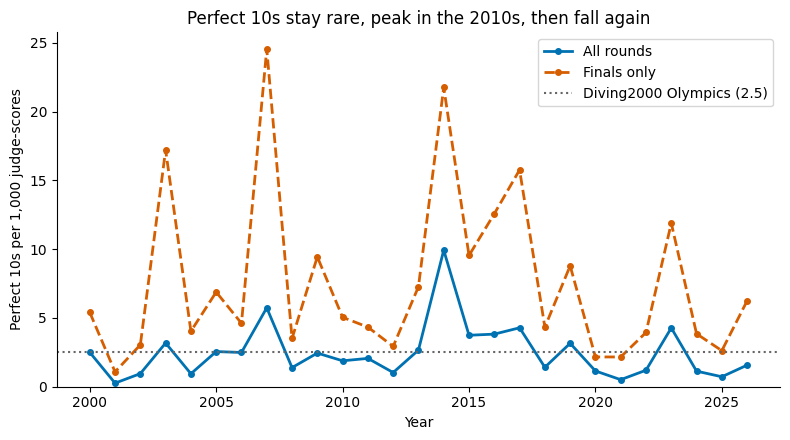

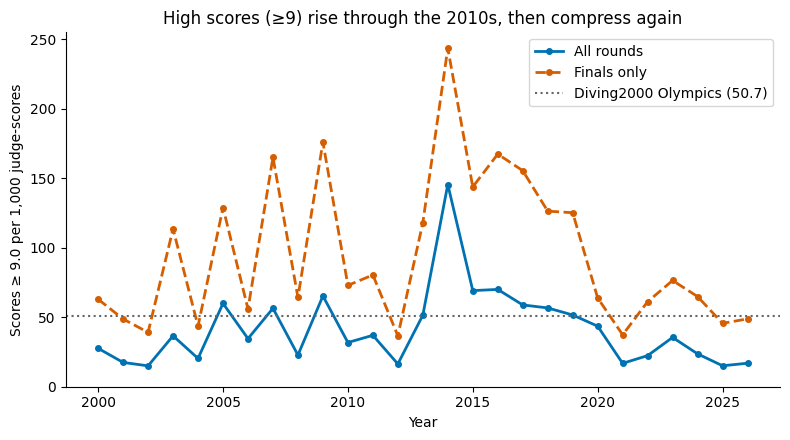

In [73]:
# drop failed dives (0s)
q3 = omega_long[omega_long["JScore"] > 0].copy()

# rates per 1,000 judge-scores by year
by_year = (
    q3.groupby("Year")
    .agg(
        n=("JScore", "size"),
        tens_per_1000=("Is10", "mean"),
        high_per_1000=("IsHigh", "mean"),
        mean_score=("JScore", "mean"),
        mean_dd=("Difficulty", "mean"),
    )
    .reset_index()
)
by_year["tens_per_1000"] = by_year["tens_per_1000"] * 1000
by_year["high_per_1000"] = by_year["high_per_1000"] * 1000

# finals only — fairer when some years have no prelims
q3_final = q3[q3["Round"] == "Final"].copy()
final_by_year = (
    q3_final.groupby("Year")
    .agg(
        n_final=("JScore", "size"),
        tens_per_1000=("Is10", "mean"),
        high_per_1000=("IsHigh", "mean"),
    )
    .reset_index()
)
final_by_year["tens_per_1000"] = final_by_year["tens_per_1000"] * 1000
final_by_year["high_per_1000"] = final_by_year["high_per_1000"] * 1000

print("Omega top-score rates by year (failed dives dropped):")
print(by_year.round(2).to_string(index=False))

# Diving2000 reference (Sydney Olympics, already long)
d2000_scored = diving2000[diving2000["JScore"] > 0]
d2000_tens = d2000_scored["Is10"].mean() * 1000
d2000_high = d2000_scored["IsHigh"].mean() * 1000
print()
print("Diving2000 (Sydney Olympics) tens per 1,000:", round(d2000_tens, 2))
print("Diving2000 (Sydney Olympics) >=9 per 1,000: ", round(d2000_high, 1))

# Q3-A: perfect 10s over time
fig, ax = plt.subplots()
ax.plot(
    by_year["Year"],
    by_year["tens_per_1000"],
    color=YEAR_COLOR,
    marker="o",
    linewidth=2,
    markersize=4,
    label="All rounds",
)
ax.plot(
    final_by_year["Year"],
    final_by_year["tens_per_1000"],
    color=FINAL_COLOR,
    marker="o",
    linewidth=2,
    markersize=4,
    linestyle="--",
    label="Finals only",
)
ax.axhline(
    d2000_tens,
    color="0.4",
    linestyle=":",
    linewidth=1.5,
    label="Diving2000 Olympics (" + str(round(d2000_tens, 1)) + ")",
)
ax.set_xlabel("Year")
ax.set_ylabel("Perfect 10s per 1,000 judge-scores")
ax.set_title("Perfect 10s by year")
ax.set_ylim(0, None)
ax.legend()
plt.tight_layout()
plt.show()

# high scores (>=9) — same layout, more events so less noisy
fig, ax = plt.subplots()
ax.plot(
    by_year["Year"],
    by_year["high_per_1000"],
    color=YEAR_COLOR,
    marker="o",
    linewidth=2,
    markersize=4,
    label="All rounds",
)
ax.plot(
    final_by_year["Year"],
    final_by_year["high_per_1000"],
    color=FINAL_COLOR,
    marker="o",
    linewidth=2,
    markersize=4,
    linestyle="--",
    label="Finals only",
)
ax.axhline(
    d2000_high,
    color="0.4",
    linestyle=":",
    linewidth=1.5,
    label="Diving2000 Olympics (" + str(round(d2000_high, 1)) + ")",
)
ax.set_xlabel("Year")
ax.set_ylabel("Scores ≥ 9.0 per 1,000 judge-scores")
ax.set_title("Scores of 9.0+ by year")
ax.set_ylim(0, None)
ax.legend()
plt.tight_layout()
plt.show()


10s have always been rare, with around 2–3 per 1,000 scores in most years, close to the 2.5 per 1,000 in the Sydney 2000 Olympics file.

They have not "disappeared" but they are not used evenly over time and the trend is moving downwards from the 2010s. The big spike in the early 2010s is during 2014. Where about 10 perfect 10s per 1,000 and about 145 scores of 9.0+ per 1,000. 

This is comapred to about 3 tens / 51 nines in 2013 and 4 tens / 69 nines in 2015. That year in this corpus is only FINA/NVC World Series stops (Beijing, Dubai, London, Monterrey, Moscow, Windsor). Those meets are invite-only, with semis and finals and no preliminaries, so the field is much stronger than a typical Worlds year. London 2014 is the most extreme stop. It is a meet mix effect, which is why it shows up in every discipline. After 2014 the rates fall again. 2025 is about 0.7 tens per 1,000 overall, and about 2.6 per 1,000 in finals.

When we look at scores of 9.0 or above, the trends are still visible but with less noise. Finals in 2000 were about 63 per 1,000; by 2014 that was about 243 per 1,000; in 2025 it is about 46 per 1,000.

There are two caviats that we need to aknowledge. 2020 has very few scores (COVID). And year totals mix championship prelims with invite-only World Series, which is why the finals-only dashed line is probably the more accurate comparison. 


## Rates by event type (3m vs 10m, men vs women)



Scores used (3m and 10m only): 392163

High scores (>=9) per 1,000 by sex and board:
Board    10m    3m
Sex               
M      110.5  32.1
W       46.7  15.8

Perfect 10s per 1,000 by sex and board:
Board   10m    3m
Sex              
M      8.99  0.82
W      3.41  0.08


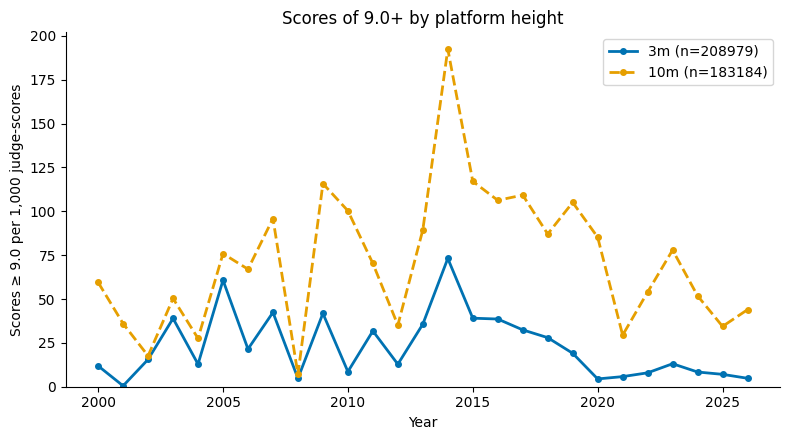

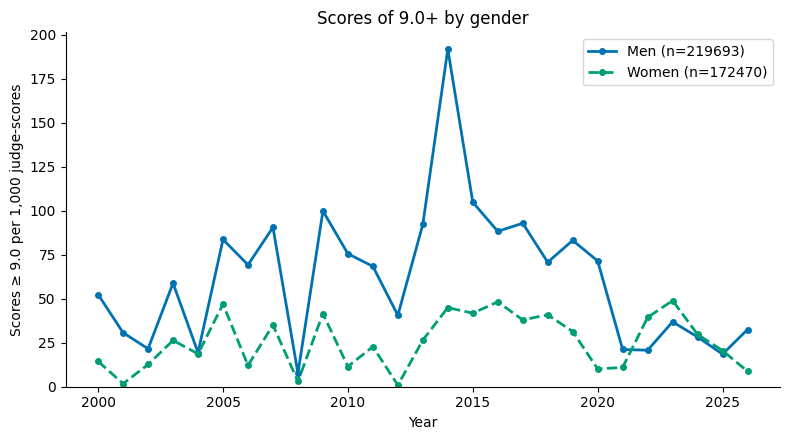

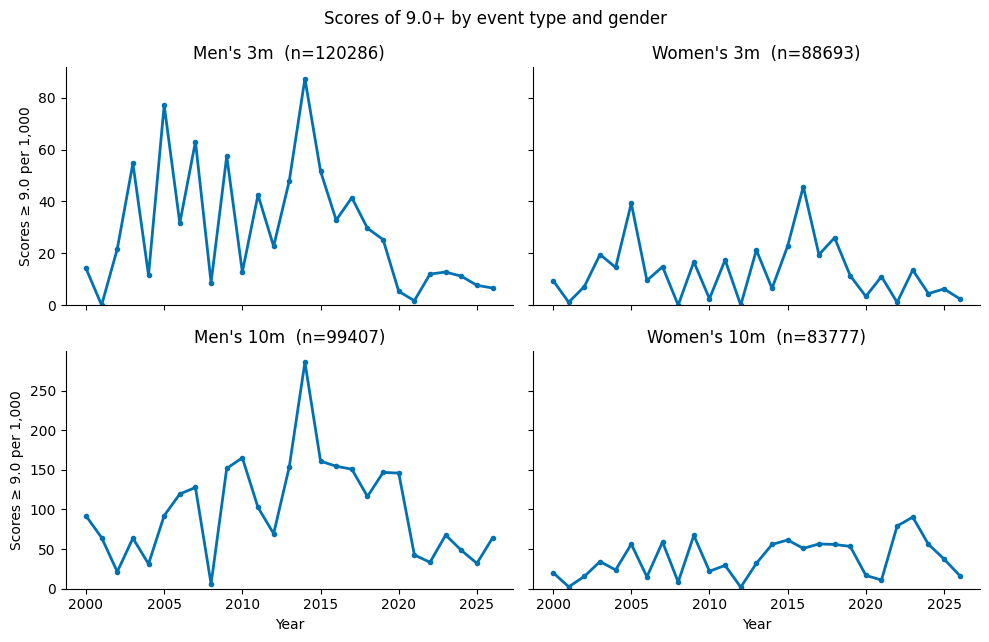

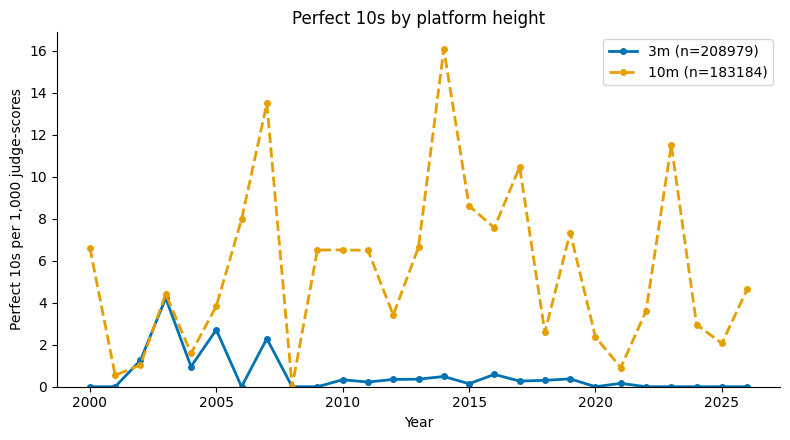

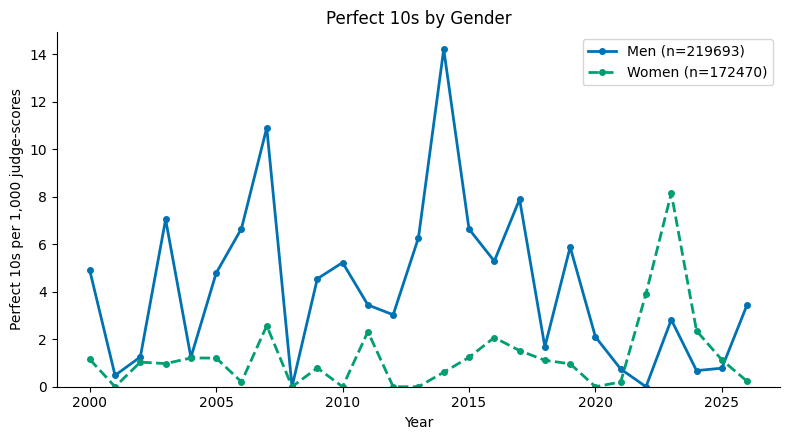

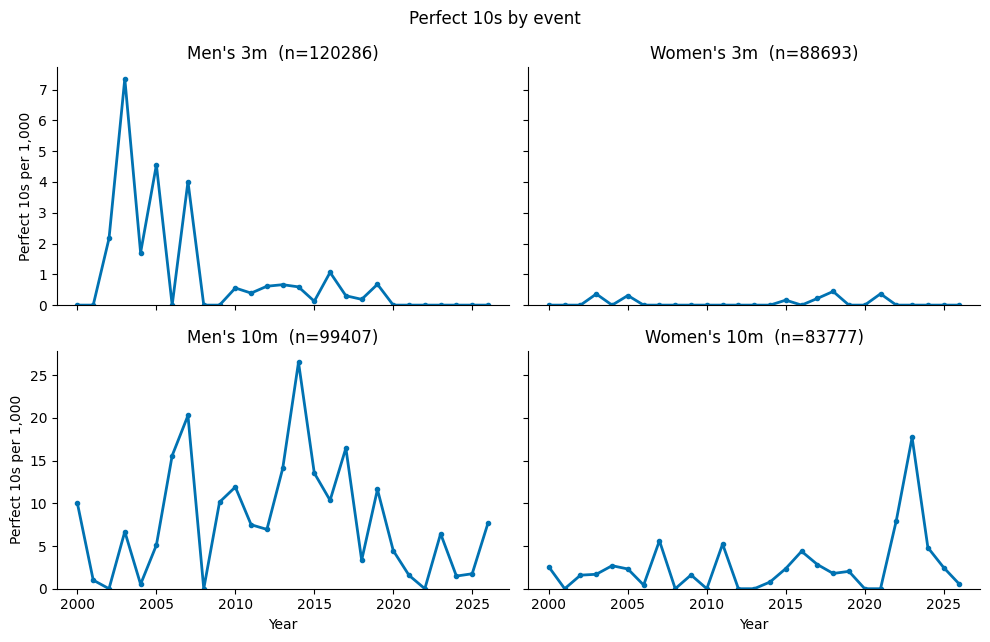

In [87]:
# board and gender from EventFamily (M3m -> M / 3m)
q3["Sex"] = q3["EventFamily"].str[0]
q3["Board"] = q3["EventFamily"].str[1:]

# 3m and 10m only; drop 1m + unlabeled
q3_events = q3[
    q3["Board"].isin(["3m", "10m"]) & q3["Sex"].isin(["M", "W"])
].copy()

print("Scores used (3m and 10m only):", len(q3_events))
print()
print("High scores (>=9) per 1,000 by sex and board:")
print(
    (q3_events.groupby(["Sex", "Board"])["IsHigh"].mean().unstack() * 1000).round(1)
)
print()
print("Perfect 10s per 1,000 by sex and board:")
print(
    (q3_events.groupby(["Sex", "Board"])["Is10"].mean().unstack() * 1000).round(2)
)

# 3m vs 10m over time
fig, ax = plt.subplots()
for board, color, ls in [("3m", YEAR_PALETTE[0], "-"), ("10m", YEAR_PALETTE[1], "--")]:
    sub = q3_events[q3_events["Board"] == board]
    rates = sub.groupby("Year")["IsHigh"].mean() * 1000
    ax.plot(
        rates.index,
        rates.values,
        color=color,
        linestyle=ls,
        marker="o",
        linewidth=2,
        markersize=4,
        label=board + " (n=" + str(len(sub)) + ")",
    )
ax.set_xlabel("Year")
ax.set_ylabel("Scores ≥ 9.0 per 1,000 judge-scores")
ax.set_title("Scores of 9.0+ by platform height")
ax.set_ylim(0, None)
ax.legend()
plt.tight_layout()
plt.show()

# men vs women 
fig, ax = plt.subplots()
for sex, label, color, ls in [
    ("M", "Men", YEAR_PALETTE[0], "-"),
    ("W", "Women", YEAR_PALETTE[2], "--"),
]:
    sub = q3_events[q3_events["Sex"] == sex]
    rates = sub.groupby("Year")["IsHigh"].mean() * 1000
    ax.plot(
        rates.index,
        rates.values,
        color=color,
        linestyle=ls,
        marker="o",
        linewidth=2,
        markersize=4,
        label=label + " (n=" + str(len(sub)) + ")",
    )
ax.set_xlabel("Year")
ax.set_ylabel("Scores ≥ 9.0 per 1,000 judge-scores")
ax.set_title("Scores of 9.0+ by gender")
ax.set_ylim(0, None)
ax.legend()
plt.tight_layout()
plt.show()

# sex × board
# share y within each row only 
fig, axes = plt.subplots(2, 2, figsize=(10, 6.5), sharex=True, sharey="row")
panels = [
    (0, 0, "M", "3m", "Men's 3m"),
    (0, 1, "W", "3m", "Women's 3m"),
    (1, 0, "M", "10m", "Men's 10m"),
    (1, 1, "W", "10m", "Women's 10m"),
]
for r, c, sex, board, title in panels:
    ax = axes[r, c]
    sub = q3_events[(q3_events["Sex"] == sex) & (q3_events["Board"] == board)]
    rates = sub.groupby("Year")["IsHigh"].mean() * 1000
    ax.plot(
        rates.index,
        rates.values,
        color=YEAR_COLOR,
        marker="o",
        linewidth=2,
        markersize=3,
    )
    ax.set_title(title + "  (n=" + str(len(sub)) + ")")

axes[0, 0].set_ylim(bottom=0)
axes[1, 0].set_ylim(bottom=0)

axes[0, 0].set_ylabel("Scores ≥ 9.0 per 1,000")
axes[1, 0].set_ylabel("Scores ≥ 9.0 per 1,000")
axes[1, 0].set_xlabel("Year")
axes[1, 1].set_xlabel("Year")
fig.suptitle("Scores of 9.0+ by event type and gender")
plt.tight_layout()
plt.show()

# same layout, perfect 10s only
fig, ax = plt.subplots()
for board, color, ls in [("3m", YEAR_PALETTE[0], "-"), ("10m", YEAR_PALETTE[1], "--")]:
    sub = q3_events[q3_events["Board"] == board]
    rates = sub.groupby("Year")["Is10"].mean() * 1000
    ax.plot(
        rates.index,
        rates.values,
        color=color,
        linestyle=ls,
        marker="o",
        linewidth=2,
        markersize=4,
        label=board + " (n=" + str(len(sub)) + ")",
    )
ax.set_xlabel("Year")
ax.set_ylabel("Perfect 10s per 1,000 judge-scores")
ax.set_title("Perfect 10s by platform height")
ax.set_ylim(0, None)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
for sex, label, color, ls in [
    ("M", "Men", YEAR_PALETTE[0], "-"),
    ("W", "Women", YEAR_PALETTE[2], "--"),
]:
    sub = q3_events[q3_events["Sex"] == sex]
    rates = sub.groupby("Year")["Is10"].mean() * 1000
    ax.plot(
        rates.index,
        rates.values,
        color=color,
        linestyle=ls,
        marker="o",
        linewidth=2,
        markersize=4,
        label=label + " (n=" + str(len(sub)) + ")",
    )
ax.set_xlabel("Year")
ax.set_ylabel("Perfect 10s per 1,000 judge-scores")
ax.set_title("Perfect 10s by Gender")
ax.set_ylim(0, None)
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 6.5), sharex=True, sharey="row")
for r, c, sex, board, title in panels:
    ax = axes[r, c]
    sub = q3_events[(q3_events["Sex"] == sex) & (q3_events["Board"] == board)]
    rates = sub.groupby("Year")["Is10"].mean() * 1000
    ax.plot(
        rates.index,
        rates.values,
        color=YEAR_COLOR,
        marker="o",
        linewidth=2,
        markersize=3,
    )
    ax.set_title(title + "  (n=" + str(len(sub)) + ")")

axes[0, 0].set_ylim(bottom=0)
axes[1, 0].set_ylim(bottom=0)
axes[0, 0].set_ylabel("Perfect 10s per 1,000")
axes[1, 0].set_ylabel("Perfect 10s per 1,000")
axes[1, 0].set_xlabel("Year")
axes[1, 1].set_xlabel("Year")
fig.suptitle("Perfect 10s by event")
plt.tight_layout()
plt.show()


10m is where the top of the scale actually gets used. Across the whole corpus, 10m has about 81 scores of 9.0+ per 1,000, versus about 25 on 3m. Perfect 10s are almost a 10m phenomenon (about 6.4 per 1,000 on 10m vs 0.5 on 3m). Both boards still show the 2010s peak and the later drop.

Men received more 9s than women for most of the series. That gap shrinks in the 2020s, and in a few recent years women are even slightly higher.

The 2×2 makes the mix clear (the 10m row is on a higher y-scale than the 3m row, so those lines are readable). The spike that hits all four panels in the early 2010s is **2014**, the World Series–only year (no prelims). It is not a 10m-only or men’s-only blip. Men’s 10m is still the high-score event (about 111 per 1,000 overall). 3m stays low for both genders, and recent 3m 9s are rarer than in 2000. Women’s 10m does **not** follow the same recent crash — if anything that line holds up better than the others.

1m is left off


## DD-banded rates and logistic regression

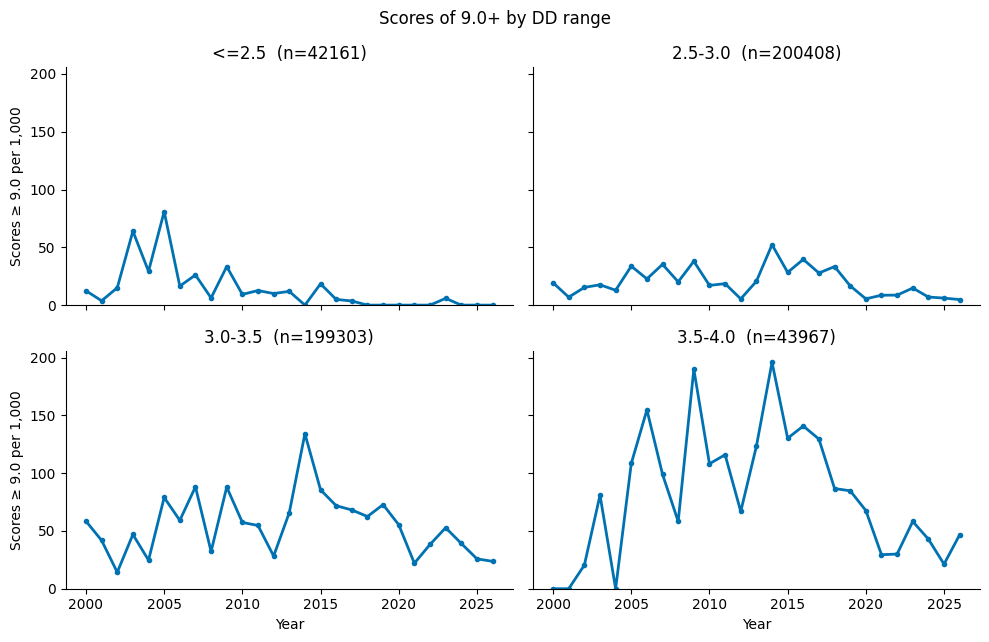

Scores of 9.0+ by DD range:
DD_band    <=2.5  2.5-3.0  3.0-3.5  3.5-4.0   >4.0
era                                               
2000-2009   39.8     24.0     61.3    117.8    NaN
2010-2019    9.5     24.4     75.5    127.3  155.6
2020-2026    0.9      8.4     36.4     39.8   81.6

Share of scores >=9 in this model data: 0.0437

Logistic coefficients (positive -> more likely to award >=9):
era_2010-2019      0.068
era_2020-2026     -0.870
DD_band_2.5-3.0   -0.169
DD_band_3.0-3.5    1.016
DD_band_3.5-4.0    1.539
DD_band_>4.0       1.884
Intercept: -3.593

Confusion matrix (rows true 0/1, cols predicted 0/1):
[[139694      0]
 [  6386      0]]

              precision    recall  f1-score   support

    not high       0.96      1.00      0.98    139694
  high (>=9)       0.00      0.00      0.00      6386

    accuracy                           0.96    146080
   macro avg       0.48      0.50      0.49    146080
weighted avg       0.91      0.96      0.93    146080



In [89]:
# high-score rates vs year inside each DD band
# skip >4.0 — only about 1,000 scores in the whole corpus
plot_bands = ["<=2.5", "2.5-3.0", "3.0-3.5", "3.5-4.0"]

fig, axes = plt.subplots(2, 2, figsize=(10, 6.5), sharex=True, sharey=True)
axes = axes.ravel()

for ax, band in zip(axes, plot_bands):
    sub = q3[q3["DD_band"] == band]
    rates = sub.groupby("Year")["IsHigh"].mean() * 1000
    ax.plot(
        rates.index,
        rates.values,
        color=YEAR_COLOR,
        marker="o",
        linewidth=2,
        markersize=3,
    )
    ax.set_title(str(band) + "  (n=" + str(len(sub)) + ")")

# zero baseline after all panels are drawn so the top fits the highest band
axes[0].set_ylim(bottom=0)

axes[0].set_ylabel("Scores ≥ 9.0 per 1,000")
axes[2].set_ylabel("Scores ≥ 9.0 per 1,000")
axes[2].set_xlabel("Year")
axes[3].set_xlabel("Year")
fig.suptitle("Scores of 9.0+ by DD range")
plt.tight_layout()
plt.show()

# era bands — a straight Year line would hide the 2010s peak
q3["era"] = pd.cut(
    q3["Year"],
    bins=[1999, 2009, 2019, 2027],
    labels=["2000-2009", "2010-2019", "2020-2026"],
)

print("Scores of 9.0+ by DD range:")
era_dd = q3.groupby(["era", "DD_band"], observed=True)["IsHigh"].mean().unstack() * 1000
print(era_dd.round(1))
print()

# logistic: IsHigh ~ era + DD_band  (hold difficulty fixed)
q3_model = q3.dropna(subset=["era", "DD_band"]).copy()
X = pd.get_dummies(q3_model[["era", "DD_band"]], drop_first=True)
y = q3_model["IsHigh"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

print("Share of scores >=9 in this model data:", round(y.mean(), 4))
print()

print("Logistic coefficients (positive -> more likely to award >=9):")
coef = pd.Series(log_model.coef_[0], index=X.columns)
print(coef.round(3).to_string())
print("Intercept:", round(log_model.intercept_[0], 3))
print()

y_pred = log_model.predict(X_test)
print("Confusion matrix (rows true 0/1, cols predicted 0/1):")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["not high", "high (>=9)"], zero_division=0))


## Distributional comparisons (histograms + ECDF)

Rates only look at the top bin. Histograms, ECDFs, and a quantile table show whether the whole score distribution shifted, or just the right tail. We use three years that span the series (2000, 2016, 2025) and the same half-point bins on every panel.


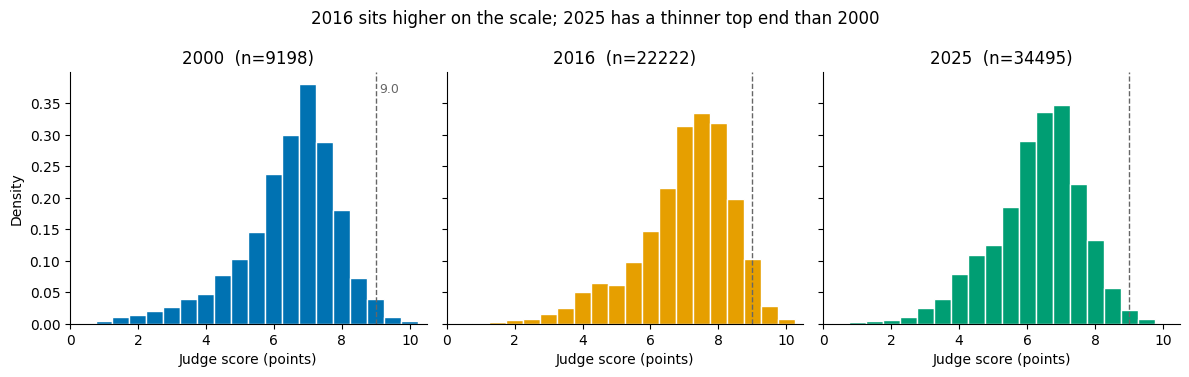

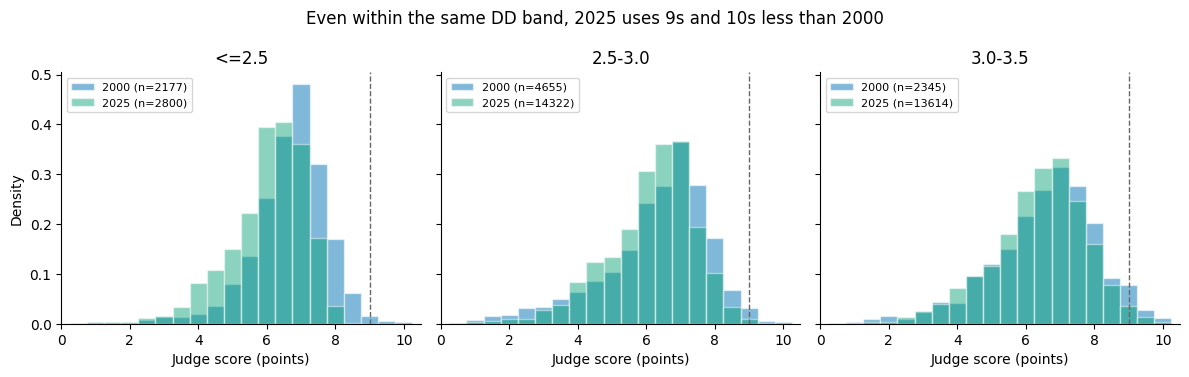

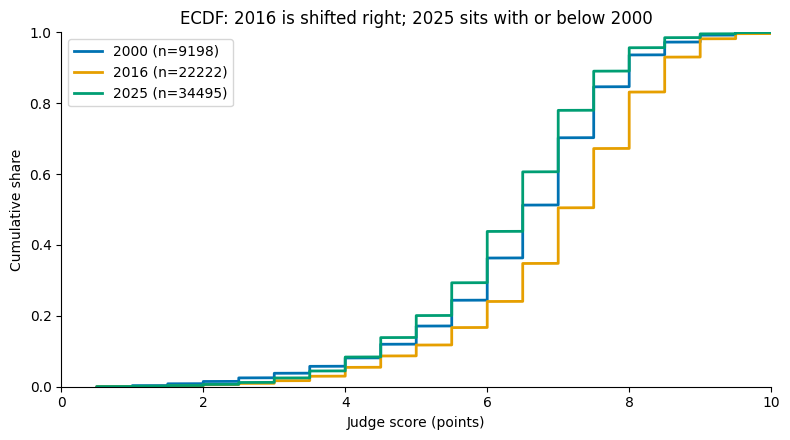

Score quantiles (failed dives dropped):
             source     n  p50  p75  p90  p95  p99  max
         Omega 2000  9198  6.5  7.5  8.0  8.5  9.0 10.0
         Omega 2016 22222  7.0  8.0  8.5  9.0  9.5 10.0
         Omega 2025 34495  6.5  7.0  8.0  8.0  9.0 10.0
Diving2000 Olympics 10786  7.0  8.0  8.5  9.0  9.5 10.0


In [76]:
# Shared half-point bins on the diving score scale
score_bins = np.arange(-0.25, 10.75, 0.5)
focus_years = [2000, 2016, 2025]

# Q3-B: one histogram per selected year (shared bins and y-axis)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)

for ax, year, color in zip(axes, focus_years, YEAR_PALETTE):
    s = q3.loc[q3["Year"] == year, "JScore"]
    ax.hist(
        s,
        bins=score_bins,
        density=True,
        color=color,
        edgecolor="white",
    )
    ax.axvline(9, color="0.4", linestyle="--", linewidth=1)
    ax.set_title(str(year) + "  (n=" + str(len(s)) + ")")
    ax.set_xlabel("Judge score (points)")
    ax.set_xlim(0, 10.5)

axes[0].set_ylabel("Density")
y_top = axes[0].get_ylim()[1]
axes[0].text(9.1, y_top * 0.92, "9.0", color="0.4", fontsize=9)
fig.suptitle("Judge score distribution by year")
plt.tight_layout()
plt.show()

# Q3-C: 2000 vs 2025 inside the DD bands that both years actually use
early, recent = 2000, 2025
compare_bands = ["<=2.5", "2.5-3.0", "3.0-3.5"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)

for ax, band in zip(axes, compare_bands):
    early_s = q3.loc[(q3["Year"] == early) & (q3["DD_band"] == band), "JScore"]
    recent_s = q3.loc[(q3["Year"] == recent) & (q3["DD_band"] == band), "JScore"]
    ax.hist(
        early_s,
        bins=score_bins,
        density=True,
        alpha=0.5,
        color=YEAR_PALETTE[0],
        edgecolor="white",
        label=str(early) + " (n=" + str(len(early_s)) + ")",
    )
    ax.hist(
        recent_s,
        bins=score_bins,
        density=True,
        alpha=0.45,
        color=YEAR_PALETTE[2],
        edgecolor="white",
        label=str(recent) + " (n=" + str(len(recent_s)) + ")",
    )
    ax.axvline(9, color="0.4", linestyle="--", linewidth=1)
    ax.set_title(str(band))
    ax.set_xlabel("Judge score (points)")
    ax.set_xlim(0, 10.5)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Density")
fig.suptitle("Judge score distribution by DD band, 2000 vs 2025")
plt.tight_layout()
plt.show()

# Q3-D: ECDF for the same three years
fig, ax = plt.subplots()
for year, color in zip(focus_years, YEAR_PALETTE):
    s = np.sort(q3.loc[q3["Year"] == year, "JScore"].dropna())
    y = np.arange(1, len(s) + 1) / len(s)
    ax.plot(s, y, color=color, linewidth=2, label=str(year) + " (n=" + str(len(s)) + ")")

ax.set_xlabel("Judge score (points)")
ax.set_ylabel("Cumulative share")
ax.set_title("ECDF of judge scores by year")
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

# quantile table for those years (and Diving2000)
print("Score quantiles (failed dives dropped):")
q_rows = []
for year in focus_years:
    s = q3.loc[q3["Year"] == year, "JScore"]
    q_rows.append(
        {
            "source": "Omega " + str(year),
            "n": len(s),
            "p50": s.quantile(0.50),
            "p75": s.quantile(0.75),
            "p90": s.quantile(0.90),
            "p95": s.quantile(0.95),
            "p99": s.quantile(0.99),
            "max": s.max(),
        }
    )
s2000 = d2000_scored["JScore"]
q_rows.append(
    {
        "source": "Diving2000 Olympics",
        "n": len(s2000),
        "p50": s2000.quantile(0.50),
        "p75": s2000.quantile(0.75),
        "p90": s2000.quantile(0.90),
        "p95": s2000.quantile(0.95),
        "p99": s2000.quantile(0.99),
        "max": s2000.max(),
    }
)
print(pd.DataFrame(q_rows).round(2).to_string(index=False))


The histograms and ECDF agree with the rate plots. 2016 is shifted toward higher scores (median and upper quantiles both up). 2025 sits with or slightly below 2000, and the bar of mass above 9 is thinner.

That pattern still shows up inside a DD band, so it is not just “lists got harder.” The 3.0–3.5 panel is the most useful comparison: both years have plenty of dives there, and 2025 has less density at 9 and 10.

The quantile table is the same story in numbers: 2016 has a higher p90/p95/p99 than 2000; 2025 does not.


## Results

The top of the scale is used less often now than in the 2010s, and perfect 10s in finals are rarer than they were in 2000. That is not only because lists got harder.

**Perfect 10s were always rare.** In the Omega corpus they run around 1–6 per 1,000 judge-scores in most years (overall about 2.7 per 1,000). The Sydney 2000 Olympics file is 2.5 per 1,000. They did not go to zero, but 2025 is down to about 0.7 per 1,000 overall and about 2.6 per 1,000 in finals (vs about 5.4 per 1,000 in Omega 2000 finals).

**2014 is the “year of the 10,” but it is a meet-mix spike.** Every 2014 meet in this corpus is a FINA/NVC World Series stop (no preliminaries). Rates jump to about 10 tens and 145 nines per 1,000, versus about 3 / 51 in 2013 and 4 / 69 in 2015. That is why the same spike appears on 3m, 10m, men, and women. London 2014 is the most extreme stop. It should not be read as judges suddenly awarding 10s everywhere that calendar year.

**High scores (≥9) tell the same story with less noise.** They rise through the 2010s and then fall. The finals-only dashed line is the fairer comparison once 2014 is set aside, and it still peaks in the 2010s and sits at or below 2000 by 2024–2026.

**Event type matters.** 10m uses 9s and 10s much more than 3m (about 81 vs 25 high scores per 1,000). Men’s 10m is the main source of top marks. 3m compression is clear for both genders. Women’s 10m does not drop the same way in recent years. The men-vs-women gap in 9s mostly closes in the 2020s.

**Difficulty does not explain the recent drop.** Mean DD went from about 2.8 to about 3.1, which should make 10s *harder* to earn. Inside the same DD band, ≥9 rates still fall in recent years. The logistic model agrees: after dummy-coding era and DD band, the 2010–2019 era is more likely to award ≥9 than 2000–2009, and 2020–2026 is less likely. High scores are only about 4% of rows, so a 0.5-threshold classifier mostly predicts “not high”; the coefficients are the useful part, not the confusion matrix.

**The whole distribution moved, not only the top bin.** 2016 sits to the right of 2000 (higher median and upper quantiles). 2025 sits with or slightly below 2000, with a thinner tail above 9. So this looks like a rise-then-compression, not a slow vanishing of the 10 from 2000 straight to today.

Caveats: 2020 has very few scores. Meet mix changes by year (Worlds prelims vs World Series). We dropped failed dives (0.0). The logistic uses era bands because a straight `Year` line would average over the 2010s peak.


## Average difficulty by event over time


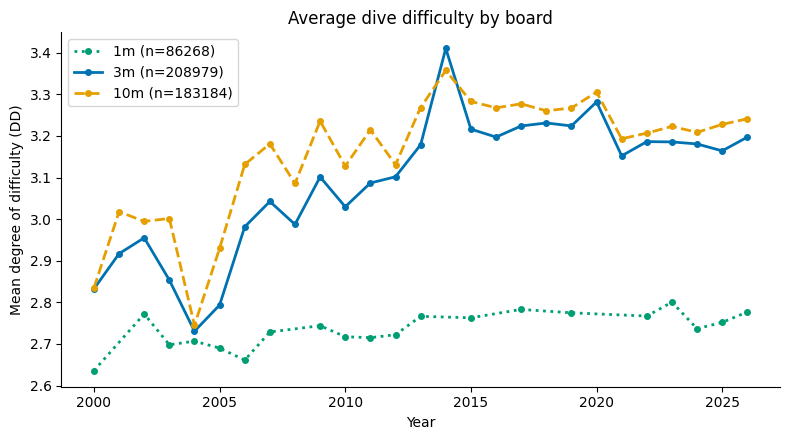

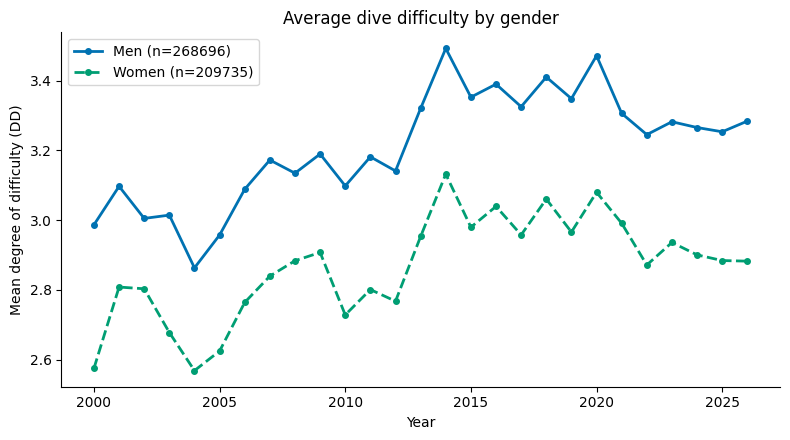

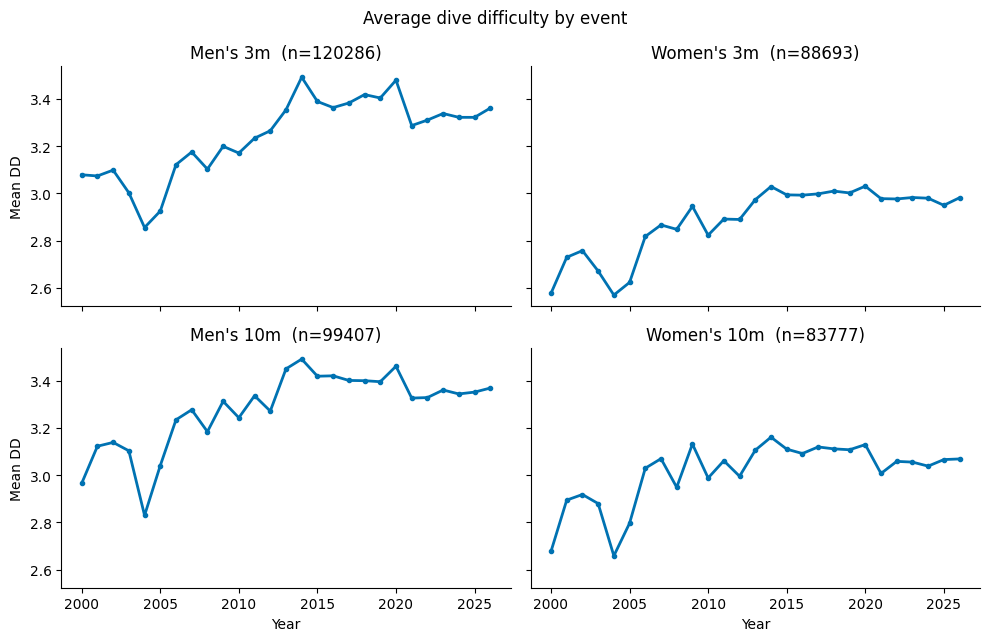

In [81]:
# mean DD vs year by board (1m / 3m / 10m)
fig, ax = plt.subplots()
for board, color, ls in [
    ("1m", YEAR_PALETTE[2], ":"),
    ("3m", YEAR_PALETTE[0], "-"),
    ("10m", YEAR_PALETTE[1], "--"),
]:
    sub = q3[q3["Board"] == board]
    means = sub.groupby("Year")["Difficulty"].mean()
    ax.plot(
        means.index,
        means.values,
        color=color,
        linestyle=ls,
        marker="o",
        linewidth=2,
        markersize=4,
        label=board + " (n=" + str(len(sub)) + ")",
    )
ax.set_xlabel("Year")
ax.set_ylabel("Mean degree of difficulty (DD)")
ax.set_title("Average dive difficulty by board")
ax.legend()
plt.tight_layout()
plt.show()

# mean DD vs year by gender
fig, ax = plt.subplots()
for sex, label, color, ls in [
    ("M", "Men", YEAR_PALETTE[0], "-"),
    ("W", "Women", YEAR_PALETTE[2], "--"),
]:
    sub = q3[q3["Sex"] == sex]
    means = sub.groupby("Year")["Difficulty"].mean()
    ax.plot(
        means.index,
        means.values,
        color=color,
        linestyle=ls,
        marker="o",
        linewidth=2,
        markersize=4,
        label=label + " (n=" + str(len(sub)) + ")",
    )
ax.set_xlabel("Year")
ax.set_ylabel("Mean degree of difficulty (DD)")
ax.set_title("Average dive difficulty by gender")
ax.legend()
plt.tight_layout()
plt.show()

# 2x2: sex × 3m / 10m
fig, axes = plt.subplots(2, 2, figsize=(10, 6.5), sharex=True, sharey=True)
panels = [
    (0, 0, "M", "3m", "Men's 3m"),
    (0, 1, "W", "3m", "Women's 3m"),
    (1, 0, "M", "10m", "Men's 10m"),
    (1, 1, "W", "10m", "Women's 10m"),
]
for r, c, sex, board, title in panels:
    ax = axes[r, c]
    sub = q3[(q3["Sex"] == sex) & (q3["Board"] == board)]
    means = sub.groupby("Year")["Difficulty"].mean()
    ax.plot(
        means.index,
        means.values,
        color=YEAR_COLOR,
        marker="o",
        linewidth=2,
        markersize=3,
    )
    ax.set_title(title + "  (n=" + str(len(sub)) + ")")

axes[0, 0].set_ylabel("Mean DD")
axes[1, 0].set_ylabel("Mean DD")
axes[1, 0].set_xlabel("Year")
axes[1, 1].set_xlabel("Year")
fig.suptitle("Average dive difficulty by event")
plt.tight_layout()
plt.show()


In [77]:
# compact summary for the writeup
def rate_per_1000(df, col):
    return df[col].mean() * 1000

q3_early = q3[q3["era"] == "2000-2009"]
q3_mid = q3[q3["era"] == "2010-2019"]
q3_recent = q3[q3["era"] == "2020-2026"]

q3_summary = pd.DataFrame(
    {
        "slice": [
            "Diving2000 Olympics",
            "Omega 2000-2009",
            "Omega 2010-2019",
            "Omega 2020-2026",
            "Omega 2000 finals",
            "Omega 2025 finals",
            "Omega 2013 (pre-spike)",
            "Omega 2014 (World Series only)",
            "Omega 2015 (post-spike)",
        ],
        "n": [
            len(d2000_scored),
            len(q3_early),
            len(q3_mid),
            len(q3_recent),
            int((q3_final["Year"] == 2000).sum()),
            int((q3_final["Year"] == 2025).sum()),
            int((q3["Year"] == 2013).sum()),
            int((q3["Year"] == 2014).sum()),
            int((q3["Year"] == 2015).sum()),
        ],
        "tens_per_1000": [
            rate_per_1000(d2000_scored, "Is10"),
            rate_per_1000(q3_early, "Is10"),
            rate_per_1000(q3_mid, "Is10"),
            rate_per_1000(q3_recent, "Is10"),
            rate_per_1000(q3_final[q3_final["Year"] == 2000], "Is10"),
            rate_per_1000(q3_final[q3_final["Year"] == 2025], "Is10"),
            rate_per_1000(q3[q3["Year"] == 2013], "Is10"),
            rate_per_1000(q3[q3["Year"] == 2014], "Is10"),
            rate_per_1000(q3[q3["Year"] == 2015], "Is10"),
        ],
        "high_per_1000": [
            rate_per_1000(d2000_scored, "IsHigh"),
            rate_per_1000(q3_early, "IsHigh"),
            rate_per_1000(q3_mid, "IsHigh"),
            rate_per_1000(q3_recent, "IsHigh"),
            rate_per_1000(q3_final[q3_final["Year"] == 2000], "IsHigh"),
            rate_per_1000(q3_final[q3_final["Year"] == 2025], "IsHigh"),
            rate_per_1000(q3[q3["Year"] == 2013], "IsHigh"),
            rate_per_1000(q3[q3["Year"] == 2014], "IsHigh"),
            rate_per_1000(q3[q3["Year"] == 2015], "IsHigh"),
        ],
    }
)
print("By era / finals:")
print(q3_summary.round(2).to_string(index=False))
print()

# event-type rates (3m / 10m only)
event_summary = (
    q3_events.groupby(["Sex", "Board"])
    .agg(
        n=("JScore", "size"),
        tens_per_1000=("Is10", "mean"),
        high_per_1000=("IsHigh", "mean"),
    )
    .reset_index()
)
event_summary["tens_per_1000"] = event_summary["tens_per_1000"] * 1000
event_summary["high_per_1000"] = event_summary["high_per_1000"] * 1000
print("By event type (3m and 10m only):")
print(event_summary.round(2).to_string(index=False))


By era / finals:
              slice      n  tens_per_1000  high_per_1000
Diving2000 Olympics  10786           2.50          50.71
    Omega 2000-2009 130923           2.57          39.85
    Omega 2010-2019 207811           3.50          60.89
    Omega 2020-2026 148197           1.67          23.06
  Omega 2000 finals   2590           5.41          62.93
  Omega 2025 finals   8008           2.62          45.58

By event type (3m and 10m only):
Sex Board      n  tens_per_1000  high_per_1000
  M   10m  99407           8.99         110.48
  M    3m 120286           0.82          32.12
  W   10m  83777           3.41          46.68
  W    3m  88693           0.08          15.75


## References

Emerson, J. W., Seltzer, M., & Lin, D. (2009). Assessing Judging Bias: An Example from the 2000 Olympic Games. *The American Statistician*, 63(2), 124–131. https://doi.org/10.1198/tast.2009.0026

Emerson, J. W., & Meredith, S. (2011). Nationalistic Judging Bias in the 2000 Olympic Diving Competition. *Math Horizons*, 18(3), 8–11. https://doi.org/10.4169/194762111x12954578042812

Diving2000 data: http://www.stat.yale.edu/~jay/diving/

Omega Timing (example): https://www.omegatiming.com/2025/diving-european-aquatics-championships-live-results